In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import joblib

In [6]:
df = pd.read_csv(
    "/content/customer_features_v3.csv"
)

print(df.shape)
df.head()

(44787, 24)


,customer_unique_id,customer_state,frequency,recency_days,monetary_value,avg_order_value,total_items_purchased,avg_freight_cost,total_orders,delivered_order_rate,...,unique_products,unique_categories,unique_sellers,avg_review_score,good_review_rate,bad_review_rate,avg_installments,total_payment_value,weekend_purchase_ratio,monthly_purchase_frequency
0,861eff4711a542e4b93843c6dd7febb0,SP,1,519,124.99,124.99,1,21.88,1,1.0,...,1,1,1,4.0,1.0,0.0,2.0,146.87,0.0,0.041667
1,290c77bc529b7ac935b93aa66c333dc3,SP,1,277,289.00,289.00,1,46.48,1,1.0,...,1,1,1,5.0,1.0,0.0,8.0,335.48,0.0,0.041667
2,060e732b5b29e8181a18229c7b0b2b5e,SP,1,151,139.94,139.94,1,17.79,1,1.0,...,1,1,1,5.0,1.0,0.0,7.0,157.73,1.0,0.041667
3,259dac757896d24d7702b9acbbff3f3c,SP,1,218,149.94,149.94,1,23.36,1,1.0,...,1,1,1,5.0,1.0,0.0,1.0,173.30,0.0,0.041667
4,345ecd01c38d18a9036ed96c73b8d066,SP,1,80,230.00,230.00,1,22.25,1,1.0,...,1,1,1,5.0,1.0,0.0,8.0,252.25,1.0,0.041667


In [7]:
customer_ids = df["customer_unique_id"]

df_model = df.drop(
    columns=[
        "customer_unique_id",
        "customer_state",
        "total_orders",
        "monthly_purchase_frequency"
    ],
    errors="ignore"
)

In [8]:
imputer = SimpleImputer(
    strategy="median"
)

df_model = pd.DataFrame(
    imputer.fit_transform(df_model),
    columns=df_model.columns
)

In [9]:
skew_cols = [
    "monetary_value",
    "avg_order_value",
    "total_payment_value",
    "avg_freight_cost"
]

for col in skew_cols:
    df_model[col] = np.log1p(
        df_model[col]
    )

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df_model
)

In [11]:
pca = PCA(
    n_components=11,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

print(X_pca.shape)

(44787, 11)


In [12]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(
    X_pca
)

In [13]:
df["cluster"] = cluster_labels

df.head()

,customer_unique_id,customer_state,frequency,recency_days,monetary_value,avg_order_value,total_items_purchased,avg_freight_cost,total_orders,delivered_order_rate,...,unique_categories,unique_sellers,avg_review_score,good_review_rate,bad_review_rate,avg_installments,total_payment_value,weekend_purchase_ratio,monthly_purchase_frequency,cluster
0,861eff4711a542e4b93843c6dd7febb0,SP,1,519,124.99,124.99,1,21.88,1,1.0,...,1,1,4.0,1.0,0.0,2.0,146.87,0.0,0.041667,0
1,290c77bc529b7ac935b93aa66c333dc3,SP,1,277,289.00,289.00,1,46.48,1,1.0,...,1,1,5.0,1.0,0.0,8.0,335.48,0.0,0.041667,0
2,060e732b5b29e8181a18229c7b0b2b5e,SP,1,151,139.94,139.94,1,17.79,1,1.0,...,1,1,5.0,1.0,0.0,7.0,157.73,1.0,0.041667,0
3,259dac757896d24d7702b9acbbff3f3c,SP,1,218,149.94,149.94,1,23.36,1,1.0,...,1,1,5.0,1.0,0.0,1.0,173.30,0.0,0.041667,0
4,345ecd01c38d18a9036ed96c73b8d066,SP,1,80,230.00,230.00,1,22.25,1,1.0,...,1,1,5.0,1.0,0.0,8.0,252.25,1.0,0.041667,0


In [14]:
cluster_sizes = (
    df["cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_sizes)

cluster
0    15575
1     5775
2    20523
3      973
4     1941
Name: count, dtype: int64


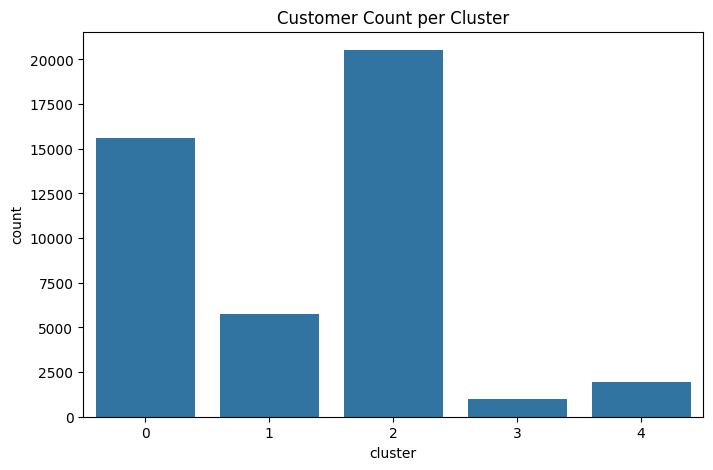

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="cluster",
    data=df
)

plt.title(
    "Customer Count per Cluster"
)

plt.show()

In [16]:
cluster_profile = (
    df.groupby("cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_profile

,frequency,recency_days,monetary_value,avg_order_value,total_items_purchased,avg_freight_cost,total_orders,delivered_order_rate,cancelled_order_rate,avg_delivery_time_days,...,unique_products,unique_categories,unique_sellers,avg_review_score,good_review_rate,bad_review_rate,avg_installments,total_payment_value,weekend_purchase_ratio,monthly_purchase_frequency
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.01,285.84,244.58,242.00,1.18,26.84,1.01,1.00,0.00,11.58,...,1.04,0.99,1.01,4.61,0.92,0.00,4.17,275.28,0.23,0.04
1,1.01,285.92,145.47,144.57,1.26,21.62,1.01,1.00,0.00,21.85,...,1.06,0.99,1.02,1.45,0.03,0.90,3.04,172.19,0.23,0.04
2,1.01,287.37,52.72,52.42,1.06,14.88,1.01,1.00,0.00,9.79,...,1.01,0.99,1.00,4.59,0.91,0.00,1.86,68.42,0.22,0.04
3,1.06,330.46,190.06,185.15,1.15,22.75,1.06,0.02,0.21,10.63,...,1.03,0.98,1.00,1.72,0.13,0.78,3.02,231.78,0.21,0.04
4,1.99,266.40,272.51,148.96,2.83,19.30,1.99,0.98,0.00,11.28,...,2.33,1.76,2.06,3.96,0.73,0.18,3.59,326.24,0.26,0.08


In [17]:
cluster_profile.to_csv(
    "cluster_profiles.csv"
)

In [18]:
cluster_revenue = (
    df.groupby("cluster")
    ["monetary_value"]
    .mean()
    .sort_values(
        ascending=False
    )
)

cluster_revenue

,monetary_value
cluster,
4,272.507810
0,244.575906
3,190.055642
1,145.469127
2,52.716605


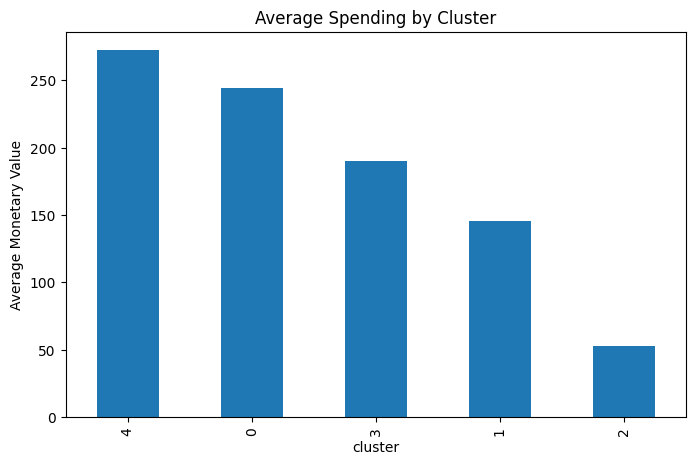

In [19]:
plt.figure(figsize=(8,5))

cluster_revenue.plot(
    kind="bar"
)

plt.title(
    "Average Spending by Cluster"
)

plt.ylabel(
    "Average Monetary Value"
)

plt.show()

In [20]:
review_analysis = (
    df.groupby("cluster")
    ["avg_review_score"]
    .mean()
)

review_analysis

,avg_review_score
cluster,
0,4.607041
1,1.445599
2,4.591077
3,1.723022
4,3.964010


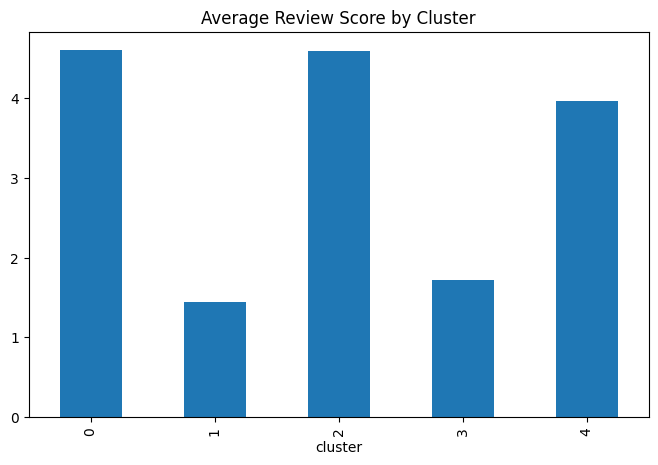

In [21]:
plt.figure(figsize=(8,5))

review_analysis.plot(
    kind="bar"
)

plt.title(
    "Average Review Score by Cluster"
)

plt.show()

In [22]:
recency_analysis = (
    df.groupby("cluster")
    ["recency_days"]
    .mean()
)

recency_analysis

,recency_days
cluster,
0,285.837881
1,285.921212
2,287.372850
3,330.462487
4,266.395672


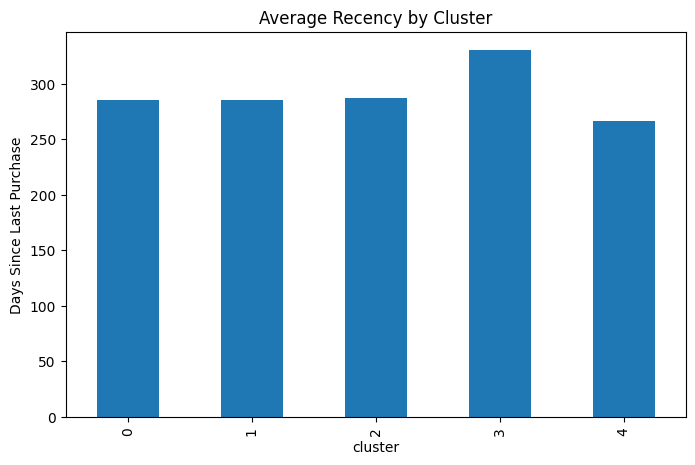

In [23]:
plt.figure(figsize=(8,5))

recency_analysis.plot(
    kind="bar"
)

plt.title(
    "Average Recency by Cluster"
)

plt.ylabel(
    "Days Since Last Purchase"
)

plt.show()

In [24]:
pca_2d = PCA(
    n_components=2,
    random_state=42
)

X_2d = pca_2d.fit_transform(
    X_scaled
)

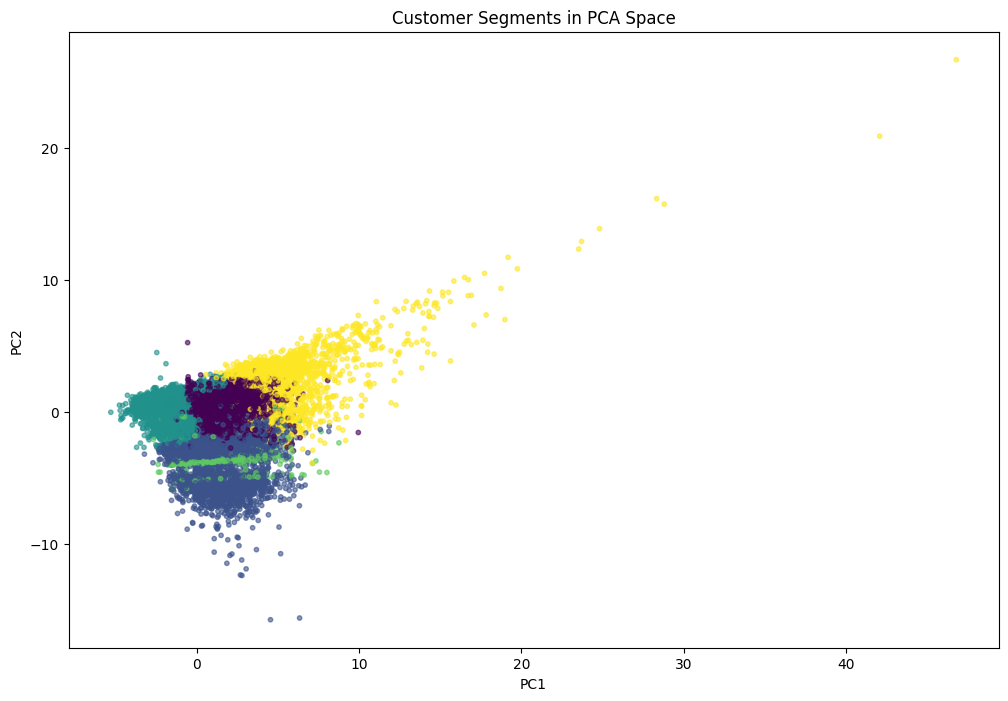

In [25]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=cluster_labels,
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Customer Segments in PCA Space"
)

plt.show()

In [26]:
joblib.dump(
    kmeans,
    "kmeans_customer_segmentation.pkl"
)

['kmeans_customer_segmentation.pkl']

In [27]:
joblib.dump(
    pca,
    "customer_pca.pkl"
)

['customer_pca.pkl']

In [28]:
joblib.dump(
    imputer,
    "customer_imputer.pkl"
)

['customer_imputer.pkl']

In [30]:
joblib.dump(
    scaler,
    "customer_scaler.pkl"
)

['customer_scaler.pkl']

In [29]:
df.to_csv(
    "customer_segments.csv",
    index=False
)

print(
    "Customer segmentation completed successfully."
)

Customer segmentation completed successfully.
